# Неделя 1 — EDA

Задание: `docs/week1_eda.md`

## 1. Загрузка данных

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append('..')
from src.eda import explore, churn_rate_by



In [8]:
# Клиенты
clients = pd.read_excel('../data/raw/clients.xlsx')

# Помесячное потребление - лежит по месяцам, читаем и склеиваем один раз,
# дальше работаем только с parquet (см. docs/data_dictionary.md)
import glob
usage_files = sorted(glob.glob('../data/raw/usage/*.csv'))
usage = pd.concat([pd.read_csv(f) for f in usage_files], ignore_index=True)

clients.to_parquet('../data/processed/clients.parquet')
usage.to_parquet('../data/processed/usage.parquet')
print(clients.shape, usage.shape)

(50400, 8) (1073079, 7)


## 2. Чек-лист EDA

Пройдитесь по 7 вопросам из `docs/week1_eda.md` для каждой таблицы.

In [9]:
# explore(clients, 'Клиенты')

# clients["is_explicit_churn"]
# clients["product"].value_counts()
# clients.duplicated().sum()
# usage.duplicated(["client_id", "month"]).sum()
# usage.boxplot(column="revenue")
numeric_columns = [
    "revenue",
    "traffic_gb",
    "n_tickets",
    "debt",
    "n_sim",
]
# (usage[numeric_columns] == 0).sum()
# usage[numeric_columns].describe(
#     percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99]
# ).T


## 3. Доля оттока по сегментам/продуктам/регионам

In [10]:
# churn_rate_by(clients, target_col='is_churned', group_col='segment')
clients["is_explicit_churn"]= (
    clients["termination_date"].notna().astype(int)
) # flag явного оттока
# clients.groupby("segment")["is_explicit_churn"].mean() * 100
# clients.groupby("region")["is_explicit_churn"].mean() * 100
# clients.groupby("product")["is_explicit_churn"].mean() * 100
# clients["is_explicit_churn"].mean()


## 4. Динамика ушедших vs оставшихся клиентов

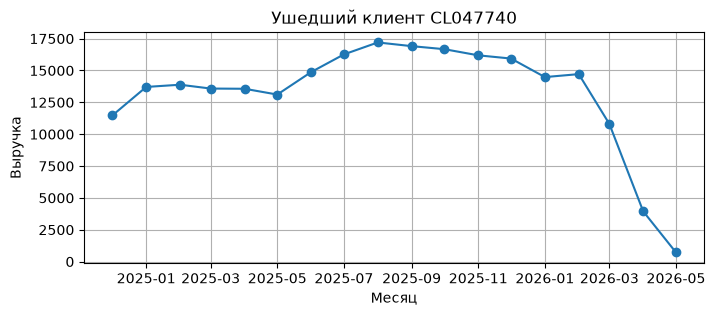

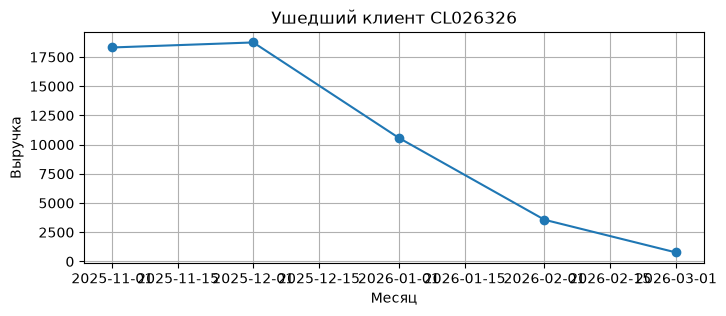

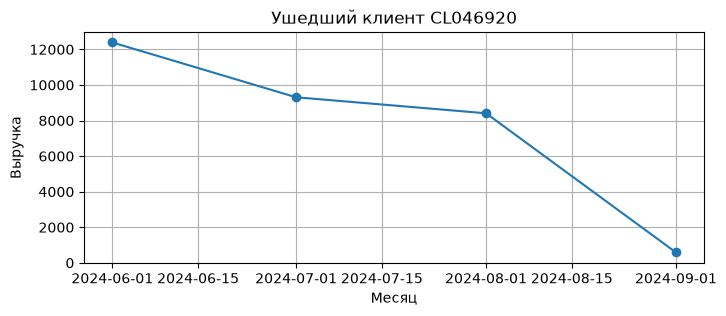

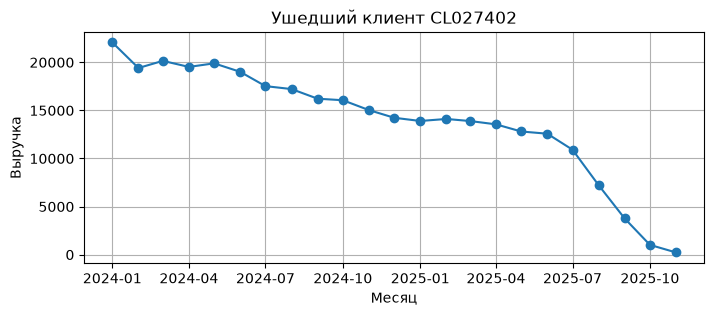

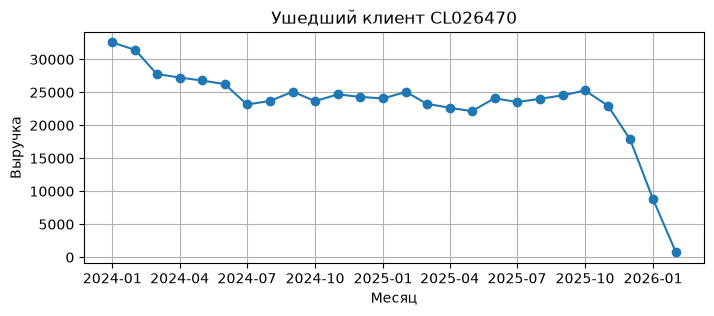

In [11]:
# TODO: построить графики revenue во времени для 5-10 ушедших и 5-10 оставшихся клиентов
usage["month"] = pd.to_datetime(usage["month"])

nonactive_ids = clients.loc[
    clients["termination_date"].notna(),
    "client_id"
].sample(5, random_state=42)

for client_id in nonactive_ids:
    history = usage[
        usage["client_id"] == client_id
    ].sort_values("month")

    plt.figure(figsize=(8, 3))
    plt.plot(
        history["month"],
        history["revenue"],
        marker="o",
    )

    plt.title(f"Ушедший клиент {client_id}")
    plt.xlabel("Месяц")
    plt.ylabel("Выручка")
    plt.grid()
    plt.show()



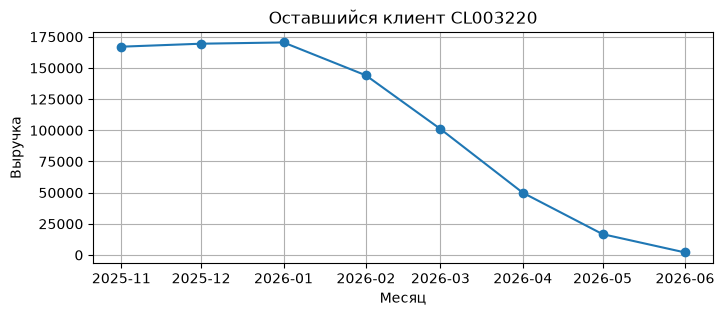

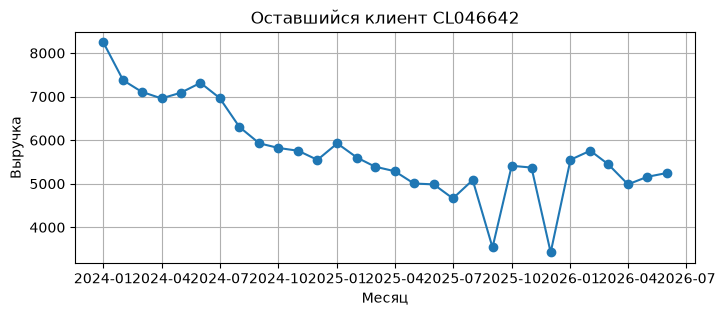

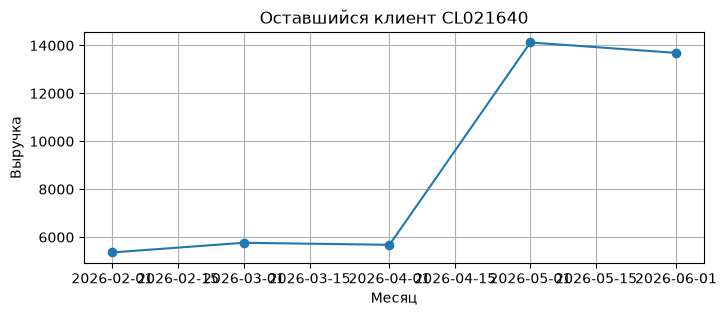

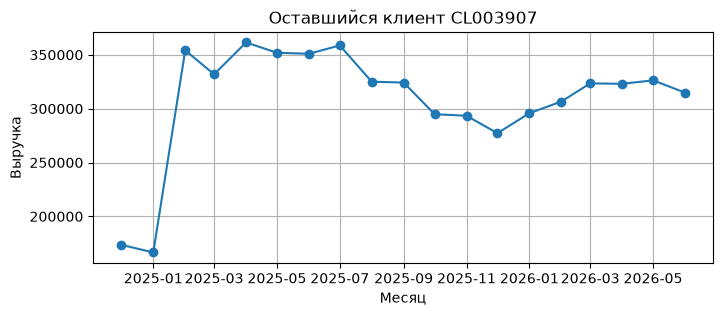

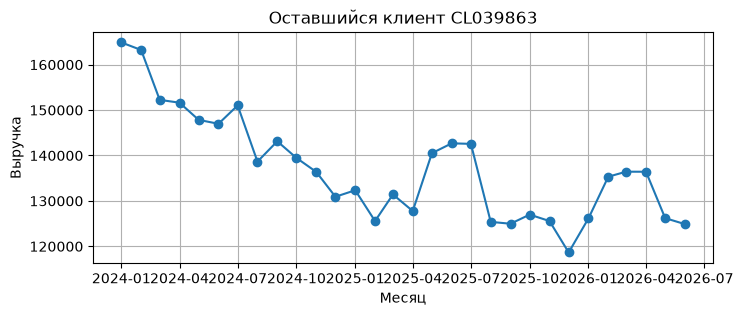

In [12]:

active_ids = clients.loc[
    clients["termination_date"].isna(),
    "client_id"
].sample(5, random_state=42)

for client_id in active_ids:
    history = usage[
        usage["client_id"] == client_id
    ].sort_values("month")

    plt.figure(figsize=(8, 3))
    plt.plot(
        history["month"],
        history["revenue"],
        marker="o",
    )

    plt.title(f"Оставшийся клиент {client_id}")
    plt.xlabel("Месяц")
    plt.ylabel("Выручка")
    plt.grid()
    plt.show()

## 5. Выводы

TODO: сформулируйте 3-5 наблюдений об аномалиях, объёме данных и первой проверке гипотезы про сегменты.

Всего клиентов 50400, записей о использование 1073079 за 30 месяцев

Дубликатов, пропусков в usage не найдено. 

Самые крупные значения выручки принадлежат одному и тому же крупному клиенту и не является ошибкой или выбросом.

По поводу гипотезы про оттоки по сегментам. Самый большой отток (30% против 27 и 20%) наблюдается среди малого бизнеса, оно и логично.

Малые бизнесы чаще меняют оператора и закрываются.    
